### Imports

In [278]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import desikan_killiany_atlas as dkatlas
import utils_a3 as utils
import watts_in_adni as nwm

import utils_a1_a3 as utils_a1
import gudhi_persistence_a3 as gp_a1

import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA

PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: C:\Users\sranasin\PycharmProjects\NetworkModels


### Tests and Visualizations

In [279]:
# reload all
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [201]:
params = {'ngeom_edges_in_persistence': True, 'max_persistence_dim': 2,
               'calculate_representation': True, 'bandwidth': 0.1,
               'resolution': 50, 'num_landscapes': 3,
               'representation_choice_function': 'persistence',
                'non_active': -1,
               'query_filter': "rid in [21, 23, 31, 10457]"
               }
adni_data_rel_path = os.path.join("resources", "TEST_NEW",
                         "structured_files_UCBERKELEY_AMY_6MM_29Oct2025", "UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv")
graph_file_rel_path = os.path.join("resources", "base_data", "DKATLAS33_base.graphml")

df = utils.df_rename_to_fsnames(adni_data_rel_path)
df = utils.safe_filter_df(df, True)
df.sort_values(by = ['rid', 'scandate'], inplace = True)
df = df.query(params.get('query_filter'))
df, feature_cols = utils.activations_cortical_regions_df(df, True)
df

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
615,1594517,011_S_0021,21,2010-10-08,2,FBP,0.0,0.0,0.0,1.007,...,0,0,1,1,1,1,0,0,0,1
616,1594530,011_S_0021,21,2012-10-03,2,FBP,0.0,0.0,-9.0,0.956,...,0,0,1,0,1,1,0,0,0,1
617,1594602,011_S_0021,21,2015-11-05,2,FBP,0.0,0.0,-11.0,0.948,...,0,0,1,0,1,1,0,0,0,1
618,1594546,011_S_0021,21,2017-11-28,2,FBP,0.0,0.0,2.0,1.016,...,1,0,1,1,1,1,0,0,0,1
619,1594569,011_S_0023,23,2010-12-21,2,FBP,1.0,0.0,21.0,1.115,...,1,0,1,1,1,1,1,1,1,1
620,1594566,011_S_0023,23,2012-12-27,2,FBP,1.0,0.0,21.0,1.117,...,0,0,1,0,1,1,0,1,0,1
621,1596213,023_S_0031,31,2010-12-01,2,FBP,1.0,1.0,39.0,1.214,...,1,1,1,0,1,1,1,0,0,1
622,1596225,023_S_0031,31,2012-09-20,2,FBP,1.0,1.0,54.0,1.291,...,0,1,0,0,1,1,1,0,0,1
623,1596160,023_S_0031,31,2016-01-26,2,FBP,1.0,1.0,73.0,1.395,...,1,1,0,0,1,1,1,0,0,1
624,1596222,023_S_0031,31,2018-04-18,2,FBP,1.0,1.0,97.0,1.518,...,1,1,1,1,1,1,1,0,1,1


In [ ]:

results_df, graph = nwm.main_sims(params=params, adni_data_file_path=adni_data_rel_path,
                                  graph_file_path=graph_file_rel_path,
                                  np_global_seed=666, save_files=False)

In [213]:
results_df[['rid', 'loniuid', 'state', 'scandate', 'time', 'num_active_nodes', 'H_0', 'H_1', 'H_2']]

,rid,loniuid,state,scandate,time,num_active_nodes,H_0,H_1,H_2
0,21,1594517,0.0,2010-10-08,0,14,1,37,0
1,21,1594530,0.0,2012-10-03,1,14,1,37,0
2,21,1594546,0.0,2017-11-28,2,22,1,112,0
3,23,1594566,1.0,2012-12-27,0,46,1,533,0
4,23,1594569,1.0,2010-12-21,1,55,1,792,0
5,31,1596160,1.0,2016-01-26,0,73,1,1113,0
6,31,1596213,1.0,2010-12-01,1,75,1,1196,0
7,31,1596222,1.0,2018-04-18,2,79,1,1382,0
8,10457,11123590,1.0,2025-02-12,0,62,1,796,0


In [204]:
results_df.columns

Index(['time', 'state', 'num_active_nodes', 'active_nodes', 'H_0', 'H_1',
       'H_2', 'L_0', 'L_1', 'L_2', 'I_0', 'I_1', 'I_2', 'E_0', 'E_1', 'E_2',
       'rid', 'scandate', 'loniuid'],
      dtype='object')

### Persistence and Functional Representation

In [236]:
# reload all
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [237]:
graph = nx.read_graphml(os.path.join(utils.BASE_DIR, graph_file_rel_path))
nx.relabel_nodes(graph, lambda x: int(x), copy=False)
params['query_filter'] = "rid in [545, 925, 1074, 1190, 1427]"
df = utils.df_rename_to_fsnames(adni_data_rel_path, query_filter=params.get('query_filter'))
df = utils.safe_filter_df(df, True)
df.sort_values(by=['rid', 'scandate'], inplace=True)
df, feature_cols = utils.activations_cortical_regions_df(df, True)
(activation_times,
snapshots,
state_values) = utils.activation_times_of_patients_for_cortical_regions_df(df,feature_cols,True)

TImestep: 0: active_nodes: [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 19, 21, 23, 28, 30, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 65, 66, 67, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]
num active nodes: 65
TImestep: 1: active_nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]
num active nodes: 76
TImestep: 2: active_nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]
num active nodes: 76
TI

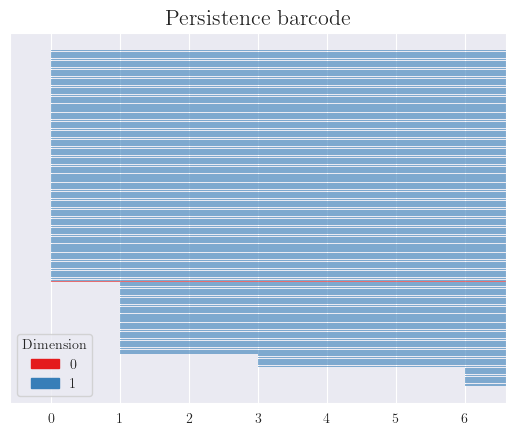

In [238]:
betti_nums, persistence, persistence_for_graphics = gp_a1.compute_persistence(
    graph=graph, activation_times=activation_times[1427],
    max_dim=2,
    ngeom_edges_in_persistence=True)
gp_a1.persistence_barcodes(persistence_for_graphics)

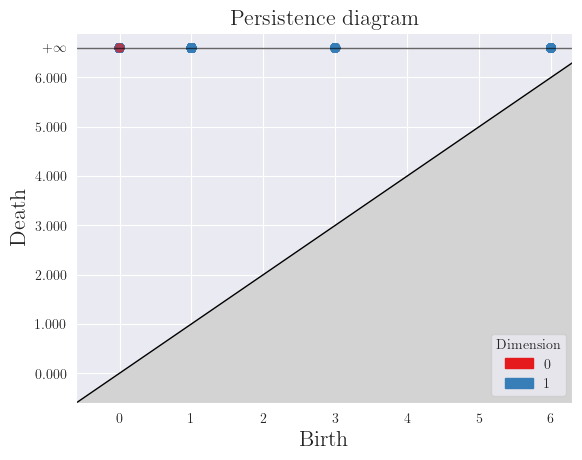

In [239]:
gp_a1.persistence_diagram(persistence_for_graphics)

### Persistence Representation

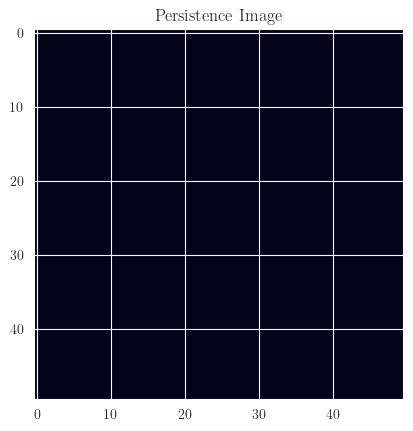

In [225]:
row_id = 7
resolution = params['resolution']
plt.imshow(np.flip(np.reshape(results_df.loc[row_id, 'I_0'], [resolution,resolution]), 0))
plt.title("Persistence Image")
plt.show()

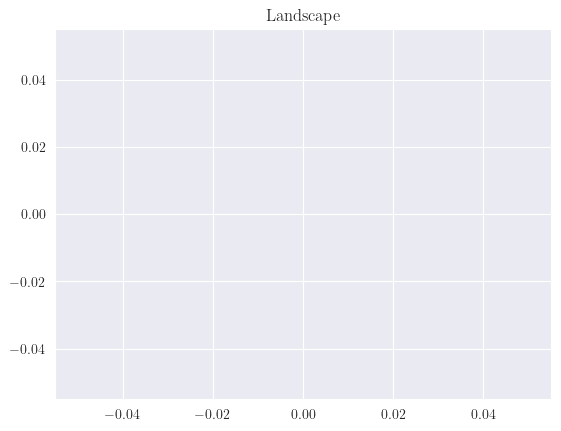

In [226]:
plt.plot(results_df.loc[row_id, 'L_0'][:resolution])
plt.plot(results_df.loc[row_id, 'L_1'][resolution: resolution*2])
plt.plot(results_df.loc[row_id, 'L_2'][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

### TEST Representation with random activatoins and trucated edges

In [208]:
# random activation arrays
length = 83
a, b = 0.5, 2.0
beta_vals = np.random.beta(a, b, size=length)
scaled_vals = beta_vals * (10 - (-1)) + (-1)
arr = np.floor(scaled_vals).astype(int)
test_activation_times = arr
print(arr)


# truncate graph edges
edges_to_set = [(u, v) for u, v in graph.edges()]
types = ['geometric', 'non_geometric']
probs = [0.4, 0.6]
for edge in edges_to_set:
    graph.edges[edge]['type'] = np.random.choice(types, p=probs)

[ 0 -1 -1  3 -1  2  8 -1  1 -1 -1 -1  4 -1  2  1  1  0  3  0 -1  0 -1  3
  6 -1  8  1  1  2  3  0  0  0  3  0 -1  0  1  1 -1  3  0 -1  2 -1 -1  6
 -1 -1 -1  3 -1  0  1  5  3 -1  0 -1  5 -1 -1  4  2  2  1 -1 -1 -1  7  2
  2  6 -1 -1  2 -1 -1 -1  2 -1  0]


In [209]:
betti_nums, persistence, persistence_for_graphics = gp_a1.compute_persistence(
    graph=graph, activation_times=test_activation_times, # activation_times[1427],
    max_dim=2,
    ngeom_edges_in_persistence=False)

removing non-geometric edges
TImestep: 0: active_nodes: [0, 17, 19, 21, 31, 32, 33, 35, 37, 42, 53, 58, 82]
num active nodes: 12
TImestep: 1: active_nodes: [0, 8, 15, 16, 17, 19, 21, 27, 28, 31, 32, 33, 35, 37, 38, 39, 42, 53, 54, 58, 66, 82]
num active nodes: 21
TImestep: 2: active_nodes: [0, 5, 8, 14, 15, 16, 17, 19, 21, 27, 28, 29, 31, 32, 33, 35, 37, 38, 39, 42, 44, 53, 54, 58, 64, 65, 66, 71, 72, 76, 80, 82]
num active nodes: 31
TImestep: 3: active_nodes: [0, 3, 5, 8, 14, 15, 16, 17, 18, 19, 21, 23, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 41, 42, 44, 51, 53, 54, 56, 58, 64, 65, 66, 71, 72, 76, 80, 82]
num active nodes: 39
TImestep: 4: active_nodes: [0, 3, 5, 8, 12, 14, 15, 16, 17, 18, 19, 21, 23, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 41, 42, 44, 51, 53, 54, 56, 58, 63, 64, 65, 66, 71, 72, 76, 80, 82]
num active nodes: 41
TImestep: 5: active_nodes: [0, 3, 5, 8, 12, 14, 15, 16, 17, 18, 19, 21, 23, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 41, 42, 44, 51, 53, 

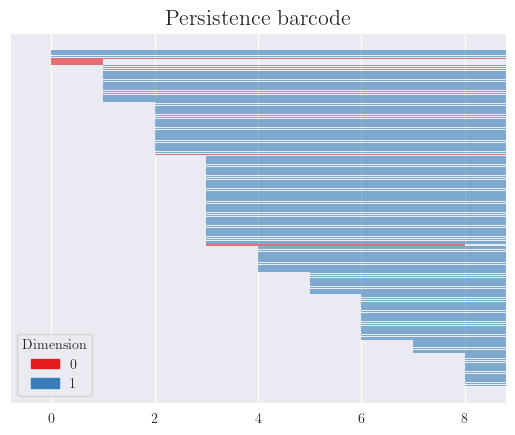

In [211]:
gp_a1.persistence_barcodes(persistence_for_graphics)

In [164]:
from collections import defaultdict
from math import inf

betti_nums_test = defaultdict(lambda: defaultdict(int))
for t in range(0, 8 + 1):
    for dim, (b, d) in persistence_for_graphics:
        if b <= t < d or (d == inf and b <= t):
            betti_nums_test[t][dim] +=1



In [165]:
betti_nums = counts
persistence =

defaultdict(<function __main__.<lambda>()>,
            {0: defaultdict(int, {1: 3, 0: 5}),
             1: defaultdict(int, {1: 5, 0: 7}),
             2: defaultdict(int, {1: 7, 0: 5}),
             3: defaultdict(int, {1: 17, 0: 5}),
             4: defaultdict(int, {1: 25, 0: 4}),
             5: defaultdict(int, {1: 29, 0: 4}),
             6: defaultdict(int, {1: 35, 0: 4}),
             7: defaultdict(int, {1: 37, 0: 4}),
             8: defaultdict(int, {1: 39, 0: 3})})

In [241]:
n_timesteps = 9
n_dims = 2
n_intervals_per_cell = 3
jitter = 0.01

persistence_test = np.empty((n_timesteps, n_dims), dtype=object)

for t in range(n_timesteps):
    for dim in range(n_dims):
        intervals = []
        for _ in range(n_intervals_per_cell):
            max_birth = min(t, 5)
            if max_birth < 0:
                continue
            birth = np.random.randint(0, max_birth + 1)


            min_death = max(birth + 3, t + 1)
            max_death = 8
            if min_death > max_death:
                continue

            death = np.random.randint(min_death, max_death + 1)

            # jitter
            birth_j = birth + np.random.uniform(0, jitter)
            death_j = death + np.random.uniform(0, jitter)

            intervals.append((birth_j, death_j))

        persistence_test[t, dim] = intervals

persistence_test


array([[list([(0.008643699884773317, 7.0059840441790255), (0.0018813318658774658, 8.005755894597081), (0.00888050873734791, 6.006127540776684)]),
        list([(0.004681793034076973, 3.00690968123929), (0.0017716442631417106, 3.0022476513791903), (0.007337436124783756, 5.005900470249524)])],
       [list([(0.0017004077181563282, 8.00757709254891), (0.008493165058703553, 6.002809717251043), (1.0025430745197335, 8.003372650766947)]),
        list([(1.0030540299531427, 5.004881705330819), (0.008416436108848142, 4.001091947688731), (1.0007633718012934, 8.009350041549917)])],
       [list([(2.0034349814953063, 8.007265227880643), (1.0055937099341985, 6.004068670101653), (0.004535410662408308, 6.000579951684572)]),
        list([(2.009503998827283, 5.008061431601132), (0.0031490763290800174, 5.008870178550547), (1.0084965408612485, 8.000258982763132)])],
       [list([(1.0022183428779432, 5.006054747630479), (1.005241919281354, 4.004035119465281), (0.007192463891571544, 8.008233990536318)]),

In [242]:
L, I, E, pers_params = gp_a1.persistence_representation_t(persistence_test,
                                                          bandwidth=params.get('bandwidth'),
                                                          persistence_surface_function = utils_a1.get_representation_choice_function(params.get("representation_choice_function", "persistence")),
                                                             resolution = resolution,
                                                             num_landscapes = 2)

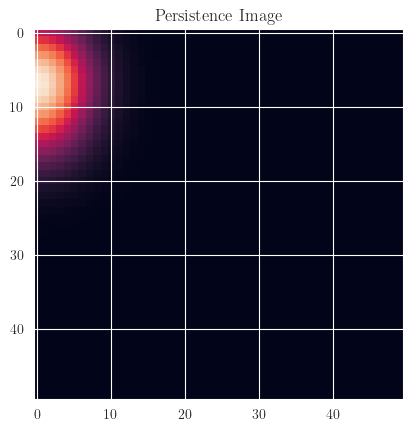

In [247]:
plt.imshow(np.flip(np.reshape(I[0][0], [resolution,resolution]), 0))
plt.title("Persistence Image")
plt.show()

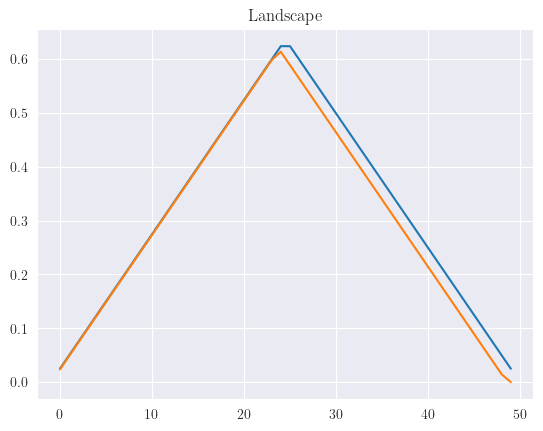

In [249]:
plt.plot(L[0][0][:resolution])
plt.plot(L[0][0][resolution: resolution*2])
plt.plot(L[0][0][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

### FLCRM / COX

In [280]:
df_adni = utils.df_rename_to_fsnames(adni_data_rel_path)
df_adni = utils.safe_filter_df(df_adni, True)
df_adni.sort_values(by = ['rid', 'scandate'], inplace = True)
# df_adni = df_adni.query(params.get('query_filter'))
df_adni, feature_cols = utils.activations_cortical_regions_df(df_adni, True)
df_adni
df_adni[df_adni['rid'] == 10025]

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity


In [281]:
params['query_filter'] = None
results_df, graph = nwm.main_sims(params=params, adni_data_file_path=adni_data_rel_path,
                                  graph_file_path=graph_file_rel_path,
                                  np_global_seed=666, save_files=False)

Patient rid: 21
Patient rid: 23
Patient rid: 31
Patient rid: 35
Patient rid: 42
Patient rid: 47
Patient rid: 56
Patient rid: 58
Patient rid: 59
Patient rid: 61
Patient rid: 69
Patient rid: 74
Patient rid: 89
Patient rid: 96
Patient rid: 101
Patient rid: 106
Patient rid: 107
Patient rid: 112
Patient rid: 113
Patient rid: 118
Patient rid: 120
Patient rid: 123
Patient rid: 126
Patient rid: 127
Patient rid: 130
Patient rid: 135
Patient rid: 138
Patient rid: 150
Patient rid: 156
Patient rid: 159
Patient rid: 160
Patient rid: 166
Patient rid: 171
Patient rid: 172
Patient rid: 173
Patient rid: 186
Patient rid: 200
Patient rid: 210
Patient rid: 214
Patient rid: 225
Patient rid: 227
Patient rid: 229
Patient rid: 230
Patient rid: 232
Patient rid: 257
Patient rid: 259
Patient rid: 260
Patient rid: 269
Patient rid: 272
Patient rid: 276
Patient rid: 285
Patient rid: 289
Patient rid: 292
Patient rid: 294
Patient rid: 295
Patient rid: 296
Patient rid: 301
Patient rid: 303
Patient rid: 307
Patient rid

In [282]:
df_temp = results_df
front_columns = ['rid', 'loniuid', 'state', 'scandate', 'time', 'num_active_nodes']

In [283]:
# keep only realizations that have at least one row with state == 1
df_temp = df_temp[df_temp.groupby(['rid'])['state'].transform('max') == 1]
df_temp = df_temp[df_temp.groupby(['rid'])['state'].cumsum() <= 1]

In [284]:

suffix_columns = [f"{prefix}_{i}" for prefix in ['H', 'L', 'I', 'E'] for i in range(3)]
all_columns = list(df_temp.columns)

middle_columns = [col for col in all_columns if col not in front_columns + suffix_columns]
df_temp = df_temp[front_columns + middle_columns + suffix_columns]
df_temp.drop(columns = suffix_columns, inplace=False).head(10)

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes
3,23,1594566,1.0,2012-12-27,0,46,"[1, 6, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, ..."
5,31,1596160,1.0,2016-01-26,0,73,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
8,35,1600172,1.0,2010-12-08,0,80,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
21,61,1596117,1.0,2015-02-10,0,74,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1..."
42,101,1594293,1.0,2012-02-16,0,74,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
43,106,1600592,1.0,2015-02-24,0,71,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
46,112,1600896,1.0,2015-05-19,0,72,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
51,120,1596536,1.0,2015-03-12,0,44,"[6, 9, 10, 13, 14, 15, 17, 19, 20, 21, 22, 23,..."
52,120,1596689,0.0,2011-02-16,1,44,"[6, 9, 10, 13, 14, 15, 17, 19, 20, 21, 22, 23,..."
53,120,1596694,0.0,2013-02-27,2,46,"[5, 6, 9, 10, 13, 14, 15, 17, 19, 20, 21, 22, ..."


In [285]:
df = df_temp
df

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes,H_0,H_1,H_2,L_0,L_1,L_2,I_0,I_1,I_2,E_0,E_1,E_2
3,23,1594566,1.0,2012-12-27,0,46,"[1, 6, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, ...",1,533,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
5,31,1596160,1.0,2016-01-26,0,73,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,1113,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
8,35,1600172,1.0,2010-12-08,0,80,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,1393,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
21,61,1596117,1.0,2015-02-10,0,74,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",1,1247,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
42,101,1594293,1.0,2012-02-16,0,74,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,1190,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381,10457,11123590,1.0,2025-02-12,0,62,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,796,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
3382,10459,11173745,1.0,2025-02-25,0,63,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,842,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
3385,10470,11183458,1.0,2025-03-05,0,83,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,1525,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
3386,10479,11173719,1.0,2025-03-19,0,46,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 19...",1,482,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0


In [308]:
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2'], how='left')


In [309]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Skipping L_0 — no valid data.
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Skipping I_0 — no valid data.
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [310]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["rid", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["rid"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])


ordered_cols = ["id", "start", "stop", "state", 'H_0', 'H_1', 'H_2'] + landscape_cols + image_cols + essentials_cols
df_pca['id'] = df['rid'].astype(str)  # + "_" + df['realization_id'].astype(str) # + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.drop(columns = ['E_0', 'E_1', 'E_2', 'H_2', 'H_0'], inplace=True)
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_12892\2758067650.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,H_1
3,23,0,1.0,1.0,533
5,31,0,1.0,1.0,1113
8,35,0,1.0,1.0,1393
21,61,0,1.0,1.0,1247
42,101,0,1.0,1.0,1190
43,106,0,1.0,1.0,1122
46,112,0,1.0,1.0,1170
51,120,0,1.0,1.0,479
52,120,1,2.0,0.0,479
53,120,2,3.0,0.0,497


### COX Model

In [312]:
from lifelines import CoxTimeVaryingFitter
ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 1151 periods, 968 subjects, 968 events>
         event col = 'state'
number of subjects = 968
 number of periods = 1151
  number of events = 968
partial log-likelihood = -5618.99
  time fit was run = 2025-11-13 18:14:10 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
H_1        0.00      1.00      0.00            0.00            0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
H_1          0.00 13.04 <0.005    126.74
---
Partial AIC = 11239.97
log-likelihood ratio test = 193.42 on 1 df
-log2(p) of ll-ratio test = 143.66

<Axes: xlabel='log(HR) (95% CI)'>

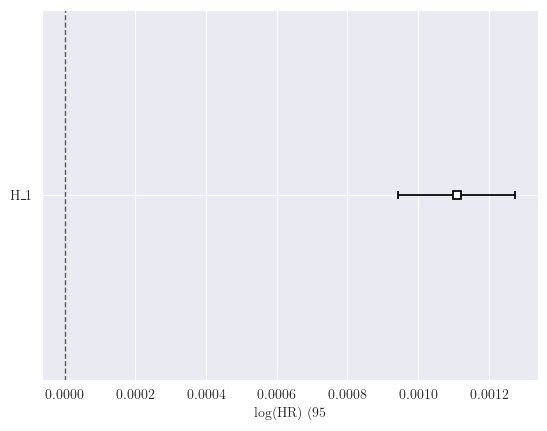

In [313]:
ctv.plot()